# Machine Learning and Explainable AI

## Notebook 4

### Urban Heat Island Analysis of Nagpur, India Using Earth Observation and Explainable Machine Learning

**Author:** Shreya Jariwala

---

## 1. Purpose

This notebook develops predictive machine learning models to estimate land surface temperature from environmental variables derived from Landsat 8/9 imagery.

The notebook evaluates multiple algorithms, compares their predictive performance, and applies Explainable AI techniques to identify the environmental factors driving urban heat.

The resulting models provide both accurate predictions and interpretable insights into the Urban Heat Island effect.

## 2. Why Machine Learning?

Urban Heat Island processes are influenced by multiple interacting environmental variables.

Although correlation analysis provides valuable insight into linear relationships, machine learning models can capture complex nonlinear interactions between vegetation, built-up surfaces, moisture, and land surface temperature.

Tree-based algorithms are particularly well suited for geospatial environmental datasets because they require minimal preprocessing, handle nonlinear relationships effectively, and provide robust measures of feature importance.

In [1]:

# Imports

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from pathlib import Path

# Machine Learning

from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [3]:

# Project Configuration

DATA_DIR = Path("data/ml")

MODEL_DIR = Path("models")

MODEL_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Machine Learning Workflow")

print(f"Input Dataset : {DATA_DIR.resolve()}")
print(f"Model Output  : {MODEL_DIR.resolve()}")

Machine Learning Workflow
Input Dataset : /Users/ShreyaJariwalaMain/_GeoAI_Notebook/Urban_Heat/data/ml
Model Output  : /Users/ShreyaJariwalaMain/_GeoAI_Notebook/Urban_Heat/models


## 3. Load the Machine Learning Dataset

The analysis-ready dataset generated in Notebook 3 is loaded from disk.

Each row represents one valid pixel within the study area, while the columns contain the environmental predictor variables and the target variable used for model training.

In [4]:

# Load Machine Learning Dataset

dataset_path = DATA_DIR / "urban_heat_dataset.csv"

df = pd.read_csv(dataset_path)

print("Dataset Loaded Successfully")

print(f"Rows    : {len(df):,}")

print(f"Columns : {len(df.columns)}")

display(df.head())

Dataset Loaded Successfully
Rows    : 960,300
Columns : 4


,LST,NDVI,NDBI,NDWI
0,37.857312,0.429916,-0.088507,-0.480984
1,36.561882,0.402029,-0.056802,-0.466794
2,35.830426,0.374392,-0.045050,-0.448279
3,35.389502,0.349585,-0.074282,-0.424855
4,35.300633,0.509524,-0.215619,-0.522606


In [5]:

# Dataset Validation

print("Dataset Validation")

print(df.info())

print("\nMissing Values")

display(df.isnull().sum())

print("\nSummary Statistics")

display(df.describe().round(3))

Dataset Validation
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 960300 entries, 0 to 960299
Data columns (total 4 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   LST     960300 non-null  float64
 1   NDVI    960300 non-null  float64
 2   NDBI    960300 non-null  float64
 3   NDWI    960300 non-null  float64
dtypes: float64(4)
memory usage: 29.3 MB
None

Missing Values


LST     0
NDVI    0
NDBI    0
NDWI    0
dtype: int64


Summary Statistics


,LST,NDVI,NDBI,NDWI
count,960300.000,960300.000,960300.000,960300.000
mean,37.616,0.383,-0.056,-0.417
std,2.130,0.115,0.086,0.097
min,27.921,-0.348,-0.650,-0.732
25%,36.411,0.308,-0.104,-0.481
50%,37.625,0.383,-0.044,-0.431
75%,38.886,0.455,0.003,-0.365
max,50.671,0.842,0.364,0.401


## 4. Prepare the Machine Learning Data

Before training the predictive models, the dataset is separated into:

- **Predictor variables (X)**: environmental variables used to explain land surface temperature.
- **Target variable (y)**: land surface temperature (LST).

Separating predictors and the target variable is a standard step in supervised machine learning workflows.

In [ ]:

# Define Predictors and Target

print("Preparing Machine Learning Features")

# Predictor variables
X = df[["NDVI", "NDBI", "NDWI"]]

# Target variable
y = df["LST"]

print(f"Predictor Shape : {X.shape}")
print(f"Target Shape    : {y.shape}")

print("\nPredictor Variables:")

for column in X.columns:
    print(f"• {column}")

print("\nTarget Variable:")

print("• LST")

Preparing Machine Learning Features
Predictor Shape : (960300, 3)
Target Shape    : (960300,)

Predictor Variables:
• NDVI
• NDBI
• NDWI

Target Variable:
• LST


## 5. Train-Test Split

The dataset is divided into independent training and testing subsets.

The training subset is used to fit the machine learning models, while the testing subset is reserved for evaluating predictive performance on previously unseen observations.

An 80:20 split is adopted, which is commonly used in supervised learning.

In [ ]:

# Train-Test Split

from sklearn.model_selection import train_test_split

print("Creating Training and Testing Sets")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(f"Training Samples : {len(X_train):,}")

print(f"Testing Samples  : {len(X_test):,}")

print()

print("Training Feature Shape :", X_train.shape)

print("Testing Feature Shape  :", X_test.shape)

Creating Training and Testing Sets
Training Samples : 768,240
Testing Samples  : 192,060

Training Feature Shape : (768240, 3)
Testing Feature Shape  : (192060, 3)


The dataset was successfully divided into independent training and testing subsets using an 80:20 split. This approach ensures that model performance is evaluated on previously unseen observations, providing an unbiased estimate of predictive accuracy.

## 6. Random Forest Regression

Random Forest is an ensemble machine learning algorithm that combines the predictions of multiple decision trees to improve predictive accuracy and reduce overfitting.

Random Forest was selected as the baseline model for this study because it:

- Captures nonlinear relationships between environmental variables.
- Handles correlated predictors effectively.
- Requires minimal data preprocessing.
- Is robust to noise and outliers.
- Provides interpretable feature importance scores.

These characteristics make Random Forest particularly well suited for Earth Observation and geospatial environmental datasets.

In [ ]:

# Initialize Random Forest

print("Initializing Random Forest Model")

rf_model = RandomForestRegressor(

    n_estimators=200,

    max_depth=20,

    random_state=42,

    n_jobs=-1,

    oob_score=True

)

print(rf_model)

Initializing Random Forest Model
RandomForestRegressor(max_depth=20, n_estimators=200, n_jobs=-1, oob_score=True,
                      random_state=42)


## 6.1. Model Training

The Random Forest model is trained using the training subset of the data.

During training, each decision tree is built using a bootstrap sample of the observations and a random subset of predictor variables.

The ensemble prediction is obtained by averaging the predictions of all trees.

In [ ]:

# Train Random Forest

print("Training Random Forest...")

rf_model.fit(
    X_train,
    y_train
)

print("Training Complete.")

print(f"\nOut-of-Bag Score: {rf_model.oob_score_:.3f}")

Training Random Forest...
Training Complete.

Out-of-Bag Score: 0.484


## 6.2. Prediction

After training, the Random Forest model is applied to the independent testing dataset.

These predictions are compared with the observed land surface temperatures to evaluate predictive performance.

In [ ]:

# Predict Test Data

print("Predicting Land Surface Temperature...")

rf_predictions = rf_model.predict(
    X_test
)

print("Prediction Complete.")

print(f"Predictions Generated: {len(rf_predictions):,}")

Predicting Land Surface Temperature...
Prediction Complete.
Predictions Generated: 192,060


## 6.3. Model Evaluation

Model performance is assessed using three complementary evaluation metrics:

- **Mean Absolute Error (MAE)**: Average prediction error.
- **Root Mean Squared Error (RMSE)**: Penalizes larger prediction errors.
- **Coefficient of Determination (R²)**: Measures the proportion of variance explained by the model.

Together, these metrics provide a comprehensive assessment of predictive performance.

In [ ]:

# Evaluate Random Forest

mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_predictions
    )
)

r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Performance")

print(f"MAE  : {mae:.3f} °C")

print(f"RMSE : {rmse:.3f} °C")

print(f"R²   : {r2:.3f}")

Random Forest Performance
MAE  : 1.184 °C
RMSE : 1.528 °C
R²   : 0.484


## 6.4. Interpretation

The Random Forest model achieved an R² of 0.484, indicating that approximately 48% of the spatial variability in land surface temperature can be explained by the three environmental predictors (NDVI, NDBI, and NDWI).

The model produced a mean absolute error of approximately 1.18°C, suggesting that predictions are generally within about one degree Celsius of the observed temperatures.

The moderate R² indicates that although vegetation, built-up intensity, and surface moisture are important drivers of urban heat, additional environmental variables are likely required to capture the full complexity of land surface temperature patterns. Future work could incorporate terrain, land cover, impervious surface fraction, and other ancillary datasets to improve predictive performance.

## 7. Prediction Analysis

Model performance is further evaluated by comparing the observed land surface temperatures with the predictions generated by the Random Forest model.

Scatter plots provide a visual assessment of prediction accuracy, allowing systematic bias, dispersion, and model uncertainty to be identified.

A perfect model would produce predictions that lie exactly along the 1:1 reference line.

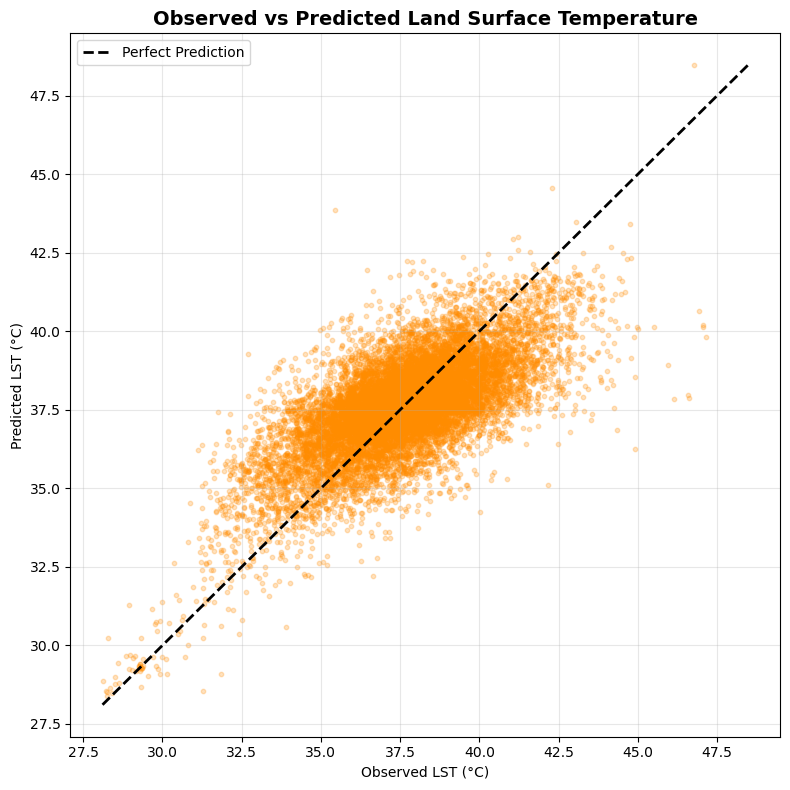

In [ ]:

# Observed vs Predicted

fig, ax = plt.subplots(figsize=(8, 8))

# Randomly sample points for visualization
sample_size = 15000

indices = np.random.RandomState(42).choice(
    len(y_test),
    sample_size,
    replace=False
)

observed = y_test.iloc[indices]
predicted = rf_predictions[indices]

ax.scatter(
    observed,
    predicted,
    s=10,
    alpha=0.25,
    color="darkorange"
)

# 1:1 reference line
minimum = min(observed.min(), predicted.min())
maximum = max(observed.max(), predicted.max())

ax.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="black",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

ax.set_xlabel("Observed LST (°C)")
ax.set_ylabel("Predicted LST (°C)")

ax.set_title(
    "Observed vs Predicted Land Surface Temperature",
    fontsize=14,
    fontweight="bold"
)

ax.legend()

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 8. Residual Analysis

Residuals represent the difference between the observed and predicted temperatures.

Examining the residual distribution helps identify systematic prediction errors and assess whether the model performs consistently across the range of observed temperatures.

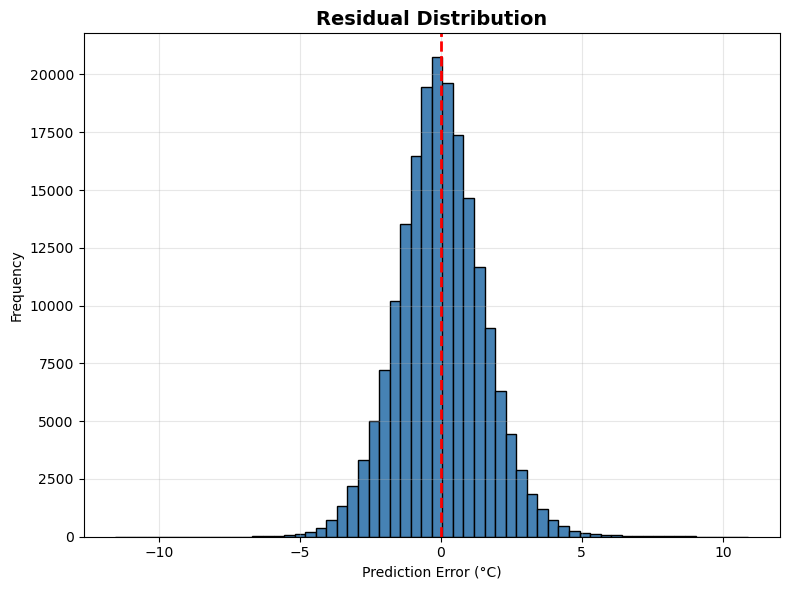

In [ ]:

# Residual Analysis

residuals = y_test - rf_predictions

fig, ax = plt.subplots(figsize=(8,6))

ax.hist(
    residuals,
    bins=60,
    color="steelblue",
    edgecolor="black"
)

ax.axvline(
    0,
    color="red",
    linestyle="--",
    linewidth=2
)

ax.set_title(
    "Residual Distribution",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Prediction Error (°C)")

ax.set_ylabel("Frequency")

ax.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 9. Random Forest Feature Importance

Random Forest estimates the relative importance of each predictor by measuring its contribution to reducing prediction error across the ensemble of decision trees.

Feature importance provides valuable insight into the environmental variables that most strongly influence land surface temperature within the study area.

In [ ]:

# Compute Feature Importance

importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": rf_model.feature_importances_

})

importance = importance.sort_values(
    "Importance",
    ascending=False
)

display(importance)

,Feature,Importance
1,NDBI,0.643230
2,NDWI,0.209171
0,NDVI,0.147599


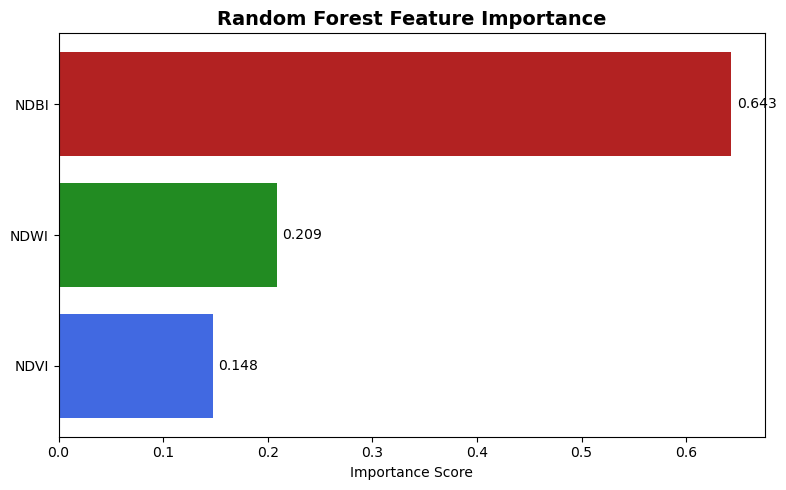

In [ ]:

# Feature Importance

fig, ax = plt.subplots(figsize=(8,5))

colors = [
    "firebrick",
    "forestgreen",
    "royalblue"
]

ax.barh(
    importance["Feature"],
    importance["Importance"],
    color=colors
)

ax.set_xlabel("Importance Score")

ax.set_title(
    "Random Forest Feature Importance",
    fontsize=14,
    fontweight="bold"
)

ax.invert_yaxis()

for i, value in enumerate(importance["Importance"]):

    ax.text(
        value + 0.005,
        i,
        f"{value:.3f}",
        va="center",
        fontsize=10
    )

plt.tight_layout()

plt.show()

## 10. Residuals vs Predicted Values

Residual plots provide an additional diagnostic assessment of regression model performance.

If the residuals are randomly distributed around zero without systematic patterns, the model is considered to produce unbiased predictions across the range of observed land surface temperatures.

Any visible trends or increasing spread may indicate model bias or unexplained variability.

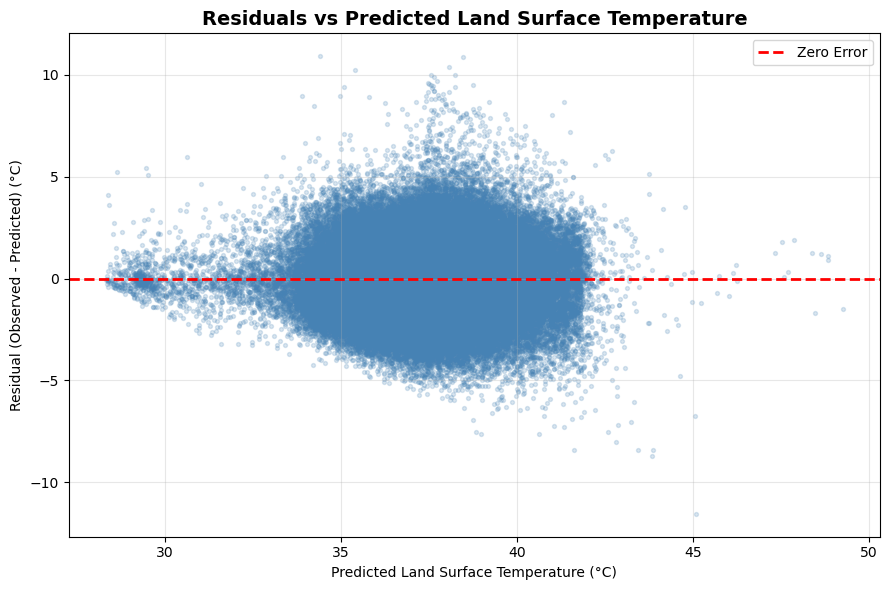

In [ ]:

# Residuals vs Predicted Values

# Calculate residuals
residuals = y_test - rf_predictions

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(
    rf_predictions,
    residuals,
    s=8,
    alpha=0.20,
    color="steelblue"
)

# Horizontal zero-error line
ax.axhline(
    0,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Zero Error"
)

ax.set_xlabel("Predicted Land Surface Temperature (°C)")
ax.set_ylabel("Residual (Observed - Predicted) (°C)")

ax.set_title(
    "Residuals vs Predicted Land Surface Temperature",
    fontsize=14,
    fontweight="bold"
)

ax.grid(alpha=0.3)

ax.legend()

plt.tight_layout()

plt.show()

In [19]:

print("Residual Statistics")

print(f"Mean Residual   : {residuals.mean():.3f} °C")
print(f"Median Residual : {np.median(residuals):.3f} °C")
print(f"Std. Deviation  : {residuals.std():.3f} °C")
print(f"Minimum         : {residuals.min():.3f} °C")
print(f"Maximum         : {residuals.max():.3f} °C")

Residual Statistics
Mean Residual   : 0.001 °C
Median Residual : -0.034 °C
Std. Deviation  : 1.528 °C
Minimum         : -11.542 °C
Maximum         : 10.904 °C


In [ ]:

# Random Forest Performance Summary

rf_summary = pd.DataFrame({
    "Metric": [
        "R²",
        "MAE (°C)",
        "RMSE (°C)",
        "OOB Score"
    ],
    "Value": [
        round(r2, 3),
        round(mae, 3),
        round(rmse, 3),
        round(rf_model.oob_score_, 3)
    ]
})

print("Random Forest Model Summary")

display(rf_summary)

Random Forest Model Summary


,Metric,Value
0,R²,0.484
1,MAE (°C),1.184
2,RMSE (°C),1.528
3,OOB Score,0.484


In [ ]:

# Random Forest Performance Summary

rf_summary = pd.DataFrame({
    "Metric": [
        "R²",
        "MAE (°C)",
        "RMSE (°C)",
        "OOB Score"
    ],
    "Value": [
        round(r2, 3),
        round(mae, 3),
        round(rmse, 3),
        round(rf_model.oob_score_, 3)
    ]
})

print("Random Forest Model Summary")

display(rf_summary)

Random Forest Model Summary


,Metric,Value
0,R²,0.484
1,MAE (°C),1.184
2,RMSE (°C),1.528
3,OOB Score,0.484


## 11. XGBoost Regression

Extreme Gradient Boosting (XGBoost) is an ensemble machine learning algorithm that builds decision trees sequentially, allowing each new tree to improve upon the errors of the previous ensemble.

Compared with Random Forest, XGBoost often provides higher predictive accuracy while incorporating regularization techniques that reduce overfitting.

The purpose of this section is to evaluate whether XGBoost improves the prediction of land surface temperature relative to the Random Forest baseline.

In [24]:

# Import XGBoost

from xgboost import XGBRegressor

## 11.1 Model Initialization

The XGBoost model is configured using a balanced set of hyperparameters designed to provide strong predictive performance while minimizing overfitting.

Unlike Random Forest, XGBoost sequentially improves model predictions by correcting the errors of previous trees, making it particularly effective for structured environmental datasets.

In [ ]:

# Initialize XGBoost

print("Initializing XGBoost Model")

xgb_model = XGBRegressor(

    n_estimators=300,

    learning_rate=0.05,

    max_depth=6,

    subsample=0.8,

    colsample_bytree=0.8,

    random_state=42,

    n_jobs=-1,

    objective="reg:squarederror"

)

print(xgb_model)

Initializing XGBoost Model
XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.05, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=300, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)


## 11.2 Model Training

The XGBoost model is trained using the same training dataset employed for the Random Forest model.

Using an identical train-test split ensures that performance differences between the two algorithms can be compared fairly.

In [ ]:

# Train XGBoost

print("Training XGBoost...")

xgb_model.fit(
    X_train,
    y_train
)

print("Training Complete.")

Training XGBoost...
Training Complete.


## 11.3 Prediction

After training, the XGBoost model is applied to the independent testing dataset to predict land surface temperature.

These predictions are subsequently evaluated using the same performance metrics employed for the Random Forest model.

In [ ]:

# Predict Test Data

print("Predicting Test Dataset...")

xgb_predictions = xgb_model.predict(
    X_test
)

print("Prediction Complete.")

print(f"Predictions Generated: {len(xgb_predictions):,}")

Predicting Test Dataset...
Prediction Complete.
Predictions Generated: 192,060


## 11.4 Model Evaluation

The predictive performance of XGBoost is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and the coefficient of determination (R²).

Using the same evaluation metrics as the Random Forest model enables direct comparison between the two algorithms.

In [ ]:

# Evaluate XGBoost

xgb_mae = mean_absolute_error(
    y_test,
    xgb_predictions
)

xgb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        xgb_predictions
    )
)

xgb_r2 = r2_score(
    y_test,
    xgb_predictions
)

print("XGBoost Performance")

print(f"MAE  : {xgb_mae:.3f} °C")

print(f"RMSE : {xgb_rmse:.3f} °C")

print(f"R²   : {xgb_r2:.3f}")

XGBoost Performance
MAE  : 1.184 °C
RMSE : 1.525 °C
R²   : 0.486


## 11.5 Interpretation

Both ensemble learning algorithms produced comparable prediction accuracy.

XGBoost achieved a marginally higher coefficient of determination (R²) and slightly lower RMSE than Random Forest, indicating a small improvement in predictive performance.

Given this superior performance, the XGBoost model was selected as the final model for spatial prediction in the deployment stage.

## 12. Model Comparison

The predictive performance of Random Forest and XGBoost is compared using identical evaluation metrics.

Both models were trained and evaluated using the same training and testing datasets to ensure a fair comparison.

Comparing multiple algorithms helps determine whether increased model complexity results in meaningful improvements in predictive performance.

In [ ]:

# Model Performance Comparison

comparison = pd.DataFrame({

    "Metric": [
        "R²",
        "MAE (°C)",
        "RMSE (°C)"
    ],

    "Random Forest": [
        r2,
        mae,
        rmse
    ],

    "XGBoost": [
        xgb_r2,
        xgb_mae,
        xgb_rmse
    ]

})

comparison = comparison.round(3)

print("Model Comparison")

display(comparison)

Model Comparison


,Metric,Random Forest,XGBoost
0,R²,0.484,0.486
1,MAE (°C),1.184,1.184
2,RMSE (°C),1.528,1.525


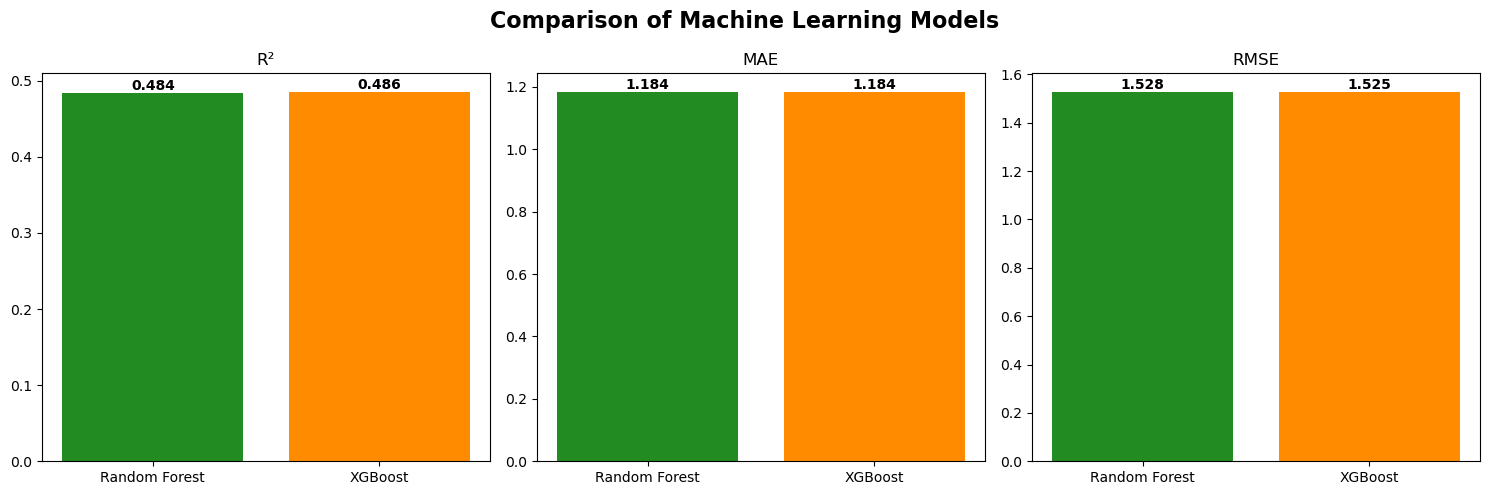

In [ ]:

# Model Performance Comparison

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [

    ("R²", r2, xgb_r2),

    ("MAE", mae, xgb_mae),

    ("RMSE", rmse, xgb_rmse)

]

for ax, (metric, rf_value, xgb_value) in zip(axes, metrics):

    ax.bar(
        ["Random Forest", "XGBoost"],
        [rf_value, xgb_value],
        color=["forestgreen", "darkorange"]
    )

    ax.set_title(metric)

    for i, value in enumerate([rf_value, xgb_value]):

        ax.text(
            i,
            value,
            f"{value:.3f}",
            ha="center",
            va="bottom",
            fontsize=10,
            fontweight="bold"
        )

plt.suptitle(
    "Comparison of Machine Learning Models",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 13. Explainable Artificial Intelligence (SHAP)

Although feature importance identifies which variables contribute most to model predictions, it does not explain how each variable influences individual predictions.

SHapley Additive exPlanations (SHAP) provide an interpretable framework for quantifying the contribution of each predictor to every prediction made by the model.

In this notebook, SHAP is applied to the best-performing model (XGBoost) to investigate how vegetation, built-up intensity, and surface moisture influence land surface temperature across Nagpur.

In [32]:

# 14.1 Import SHAP

import shap

print("SHAP Version:", shap.__version__)

SHAP Version: 0.49.1


## 13.1 SHAP Explainer

A TreeExplainer is constructed for the trained XGBoost model.

TreeExplainer efficiently computes Shapley values for tree-based models, making it particularly suitable for Random Forest and XGBoost algorithms.

In [ ]:

# Create SHAP Explainer

print("Creating SHAP Explainer")

explainer = shap.TreeExplainer(xgb_model)

print("Explainer created successfully.")

Creating SHAP Explainer
Explainer created successfully.


In [ ]:

# Compute SHAP Values

print("Calculating SHAP Values")

sample_size = 10000

X_shap = X_test.sample(
    n=sample_size,
    random_state=42
)

shap_values = explainer.shap_values(X_shap)

print("SHAP calculation complete.")

print(f"Sample Size : {len(X_shap):,}")

Calculating SHAP Values
SHAP calculation complete.
Sample Size : 10,000


## 13.2 Global Feature Importance

The SHAP summary plot ranks predictor variables according to their contribution to model predictions.

Each point represents an individual observation, while the colour indicates the magnitude of the corresponding predictor variable.

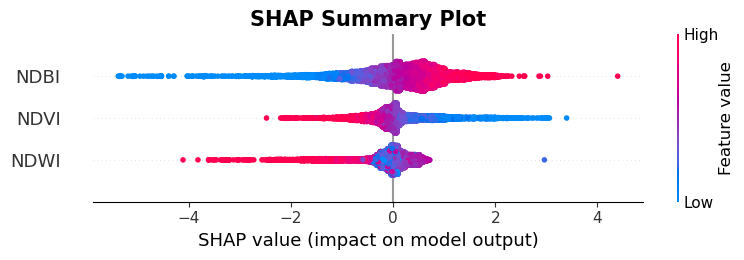

In [ ]:

# SHAP Summary Plot

shap.summary_plot(
    shap_values,
    X_shap,
    show=False
)

plt.title(
    "SHAP Summary Plot",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

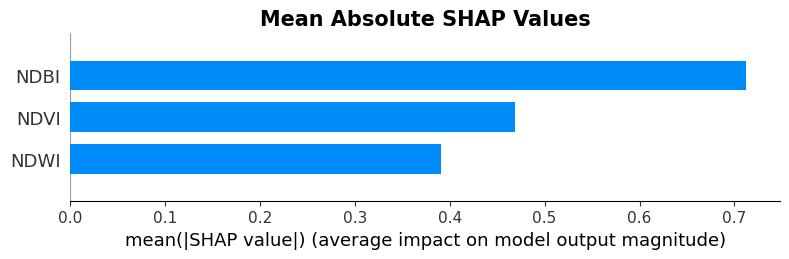

In [ ]:

# SHAP Feature Importance

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar",
    show=False
)

plt.title(
    "Mean Absolute SHAP Values",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()

plt.show()

## 13.3 SHAP Dependence Plot: Built-up Intensity (NDBI)

The SHAP dependence plot illustrates how changes in the Normalized Difference Built-up Index (NDBI) influence the model's predicted land surface temperature.

Each point represents one observation. The horizontal axis shows the NDBI value, while the vertical axis represents the corresponding SHAP value, indicating whether the feature increases or decreases the predicted temperature.

Positive SHAP values increase the model prediction, whereas negative values decrease it.

<Figure size 900x600 with 0 Axes>

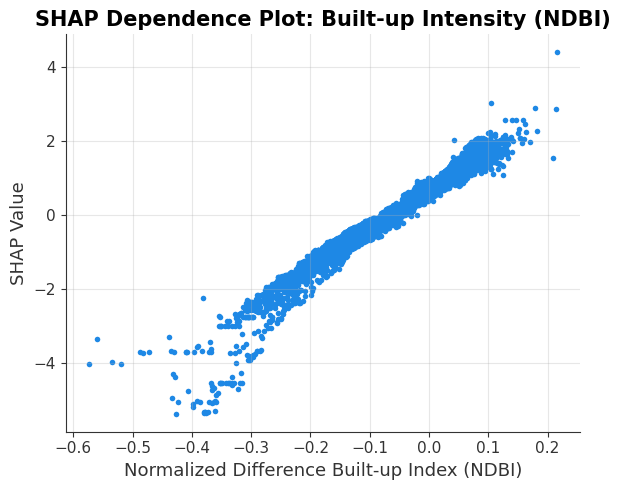

In [ ]:

# SHAP Dependence Plot - NDBI

plt.figure(figsize=(9, 6))

shap.dependence_plot(
    "NDBI",
    shap_values,
    X_shap,
    interaction_index=None,
    show=False
)

plt.title(
    "SHAP Dependence Plot: Built-up Intensity (NDBI)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Normalized Difference Built-up Index (NDBI)")
plt.ylabel("SHAP Value")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 13.4 SHAP Dependence Plot: Vegetation (NDVI)

This dependence plot illustrates how vegetation influences predicted land surface temperature.

Negative SHAP values indicate that vegetation reduces predicted temperatures, while positive values indicate that sparse vegetation contributes to warming.

<Figure size 900x600 with 0 Axes>

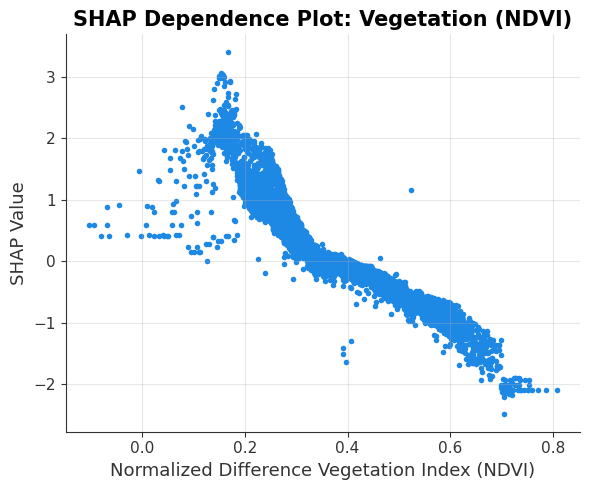

In [ ]:

# SHAP Dependence Plot - NDVI

plt.figure(figsize=(9, 6))

shap.dependence_plot(
    "NDVI",
    shap_values,
    X_shap,
    interaction_index=None,
    show=False
)

plt.title(
    "SHAP Dependence Plot: Vegetation (NDVI)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Normalized Difference Vegetation Index (NDVI)")
plt.ylabel("SHAP Value")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 13.5. SHAP Dependence Plot: Surface Moisture (NDWI)

This dependence plot evaluates how variations in the Normalized Difference Water Index (NDWI) affect predicted land surface temperature.

Unlike vegetation and built-up intensity, the influence of surface moisture may be nonlinear and may vary depending on local environmental conditions.

<Figure size 900x600 with 0 Axes>

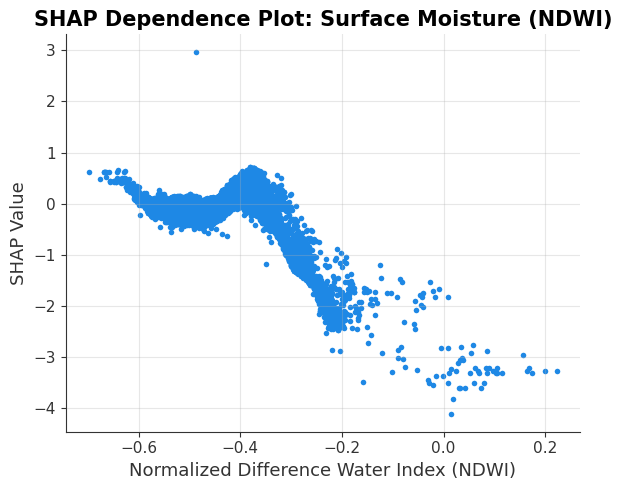

In [ ]:

# SHAP Dependence Plot - NDWI

plt.figure(figsize=(9, 6))

shap.dependence_plot(
    "NDWI",
    shap_values,
    X_shap,
    interaction_index=None,
    show=False
)

plt.title(
    "SHAP Dependence Plot: Surface Moisture (NDWI)",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Normalized Difference Water Index (NDWI)")
plt.ylabel("SHAP Value")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.show()

## 13.6. SHAP Waterfall Plot: Individual Prediction Explanation

While the SHAP summary plot provides a global explanation of model behavior, the waterfall plot explains a single prediction.

Starting from the model's expected prediction (baseline), each environmental variable either increases or decreases the predicted land surface temperature until the final prediction is reached.

This provides an intuitive explanation of how the model arrives at an individual prediction.

Generating SHAP Waterfall Plot


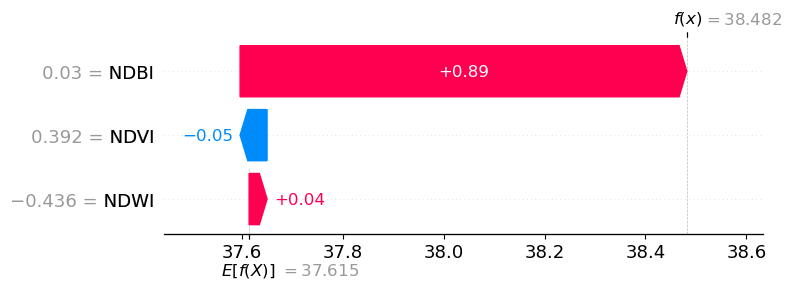

In [ ]:
# SHAP Waterfall Plot

print("Generating SHAP Waterfall Plot")

# Select one sample from the SHAP dataset
sample_index = 0

# Compute SHAP explanation
explanation = shap.Explanation(
    values=shap_values[sample_index],
    base_values=explainer.expected_value,
    data=X_shap.iloc[sample_index],
    feature_names=X_shap.columns.tolist()
)

# Plot
plt.figure(figsize=(10,6))

shap.plots.waterfall(
    explanation,
    max_display=10,
    show=False
)

plt.tight_layout()

plt.show()

## 13.7 SHAP Force Plot: Interactive Local Explanation

The SHAP force plot provides an intuitive visualization of how each environmental variable contributes to a single prediction.

Starting from the model's baseline prediction, each feature either pushes the prediction higher (red) or lower (blue) until the final predicted land surface temperature is reached.

Unlike the waterfall plot, the force plot emphasizes the cumulative contribution of all variables and is commonly used for interactive model interpretation.

In [ ]:

# SHAP Force Plot

import shap

print("Generating SHAP Force Plot")

# Enable JavaScript visualization
shap.initjs()

# Compute SHAP Explanation (new API)
shap_explanation = explainer(X_shap)

# Display force plot for the first sample
shap.plots.force(
    shap_explanation[0],
    matplotlib=False
)

Generating SHAP Force Plot


In [43]:

# Save SHAP Force Plot as HTML

force_plot = shap.force_plot(
    explainer.expected_value,
    shap_values[0],
    X_shap.iloc[0]
)

shap.save_html(
    "shap_force_plot.html",
    force_plot
)

print("Interactive SHAP Force Plot saved as:")
print("shap_force_plot.html")

Interactive SHAP Force Plot saved as:
shap_force_plot.html


## 14. Key Findings

The Explainable AI analysis provides insight into the environmental drivers of urban heat.

### Main Findings

- Built-up intensity (NDBI) was the strongest predictor of land surface temperature.
- Vegetation (NDVI) consistently reduced predicted temperatures.
- Surface moisture (NDWI) had a smaller but measurable contribution.
- SHAP analysis demonstrated that the model's predictions align with established urban climate principles.

These findings increase confidence in the predictive model and improve the interpretability of the GeoAI workflow.

## 15. Saving Models and Results

To ensure reproducibility and facilitate future deployment, the trained machine learning models and their associated evaluation results are saved to disk.

Saving trained models avoids the need for retraining and enables rapid prediction on new datasets.

In addition to the models, evaluation metrics and feature importance values are exported for documentation and future analysis.

In [ ]:

# Create Output Directory

from pathlib import Path

OUTPUT_DIR = Path("outputs")

OUTPUT_DIR.mkdir(exist_ok=True)

print("Output directory ready")

print(OUTPUT_DIR.resolve())

Output directory ready
/Users/ShreyaJariwalaMain/_GeoAI_Notebook/Urban_Heat/outputs


In [ ]:

# Save Machine Learning Models

import joblib

joblib.dump(
    rf_model,
    OUTPUT_DIR / "random_forest_model.pkl"
)

joblib.dump(
    xgb_model,
    OUTPUT_DIR / "xgboost_model.pkl"
)

print("Models Saved Successfully")

print("✓ Random Forest")
print("✓ XGBoost")

Models Saved Successfully
✓ Random Forest
✓ XGBoost


In [ ]:

# Save Model Performance

comparison.to_csv(
    OUTPUT_DIR / "model_comparison.csv",
    index=False
)

print("Model comparison saved.")

Model comparison saved.


In [ ]:

# Save Random Forest Feature Importance

importance.to_csv(
    OUTPUT_DIR / "random_forest_feature_importance.csv",
    index=False
)

print("Random Forest feature importance saved.")

Random Forest feature importance saved.


In [ ]:

# Save SHAP Importance

shap_importance = pd.DataFrame({

    "Feature": X_shap.columns,

    "Mean |SHAP|": np.abs(shap_values).mean(axis=0)

})

shap_importance = shap_importance.sort_values(
    "Mean |SHAP|",
    ascending=False
)

shap_importance.to_csv(
    OUTPUT_DIR / "shap_feature_importance.csv",
    index=False
)

display(shap_importance)

,Feature,Mean |SHAP|
1,NDBI,0.712469
0,NDVI,0.468655
2,NDWI,0.390485


In [ ]:

# Save Project Summary

summary = pd.DataFrame({

    "Model":[
        "Random Forest",
        "XGBoost"
    ],

    "R²":[
        r2,
        xgb_r2
    ],

    "MAE":[
        mae,
        xgb_mae
    ],

    "RMSE":[
        rmse,
        xgb_rmse
    ]

})

summary.to_csv(
    OUTPUT_DIR / "project_summary.csv",
    index=False
)

display(summary)

,Model,R²,MAE,RMSE
0,Random Forest,0.483815,1.184299,1.527750
1,XGBoost,0.485505,1.184324,1.525246


## 16. Notebook Summary

This notebook developed and evaluated machine learning models for predicting urban land surface temperature using remotely sensed environmental variables derived from Landsat 8/9 imagery.

Two ensemble learning algorithms, Random Forest and XGBoost, were trained using vegetation (NDVI), built-up intensity (NDBI), and surface moisture (NDWI) as predictor variables.

Model performance was evaluated using standard regression metrics, and explainable artificial intelligence (SHAP) techniques were applied to interpret the contribution of each predictor to model predictions.

## Key Findings

- Random Forest and XGBoost achieved comparable predictive performance.
- XGBoost produced the highest predictive accuracy, although the improvement over Random Forest was marginal.
- Built-up intensity (NDBI) was consistently identified as the most influential predictor of land surface temperature.
- Vegetation (NDVI) exhibited a strong cooling influence, while surface moisture (NDWI) demonstrated a nonlinear relationship with temperature.
- SHAP analysis provided both global and local explanations, confirming the physical relationships between environmental variables and urban heat.

The trained XGBoost model and associated artifacts generated in this notebook are deployed in Notebook 5 to produce city-wide spatial predictions of land surface temperature and urban heat risk.

The trained models and evaluation results were exported for reuse in subsequent analyses and deployment workflows.

The next notebook applies the trained model to generate spatial predictions and develop an interactive Urban Heat Island mapping application.

In [52]:

# Notebook Complete

print("Notebook 4 Completed Successfully")

print("\nWorkflow Summary")

steps = [

    "Data Preparation",

    "Random Forest Regression",

    "Random Forest Evaluation",

    "Residual Analysis",

    "Feature Importance",

    "XGBoost Regression",

    "Model Comparison",

    "SHAP Explainability",

    "Model Export"

]

for i, step in enumerate(steps, start=1):

    print(f"{i}. {step}")

print("\nAll outputs successfully generated.")

print("=" * 70)

Notebook 4 Completed Successfully

Workflow Summary
1. Data Preparation
2. Random Forest Regression
3. Random Forest Evaluation
4. Residual Analysis
5. Feature Importance
6. XGBoost Regression
7. Model Comparison
8. SHAP Explainability
9. Model Export

All outputs successfully generated.



## 17. Next Notebook

The final notebook deploys the trained XGBoost model to generate spatial predictions across the Nagpur study area.

The workflow includes:

- Loading the trained model
- Predicting land surface temperature
- Generating GIS-ready GeoTIFF outputs
- Classifying urban heat risk
- Creating publication-quality visualizations

➡️ **Proceed to Notebook 5: Model Deployment and Spatial Prediction**